## Cellule 1 — Installation

In [1]:
!pip install -q ipywidgets opencv-python-headless
import IPython
print(f"Pret  (IPython {IPython.__version__})")
print("Si les widgets n'apparaissent pas : View -> Table of Contents -> activer widgets")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 29.1 MB/s eta 0:00:00
Pret  (IPython 7.34.0)
Si les widgets n'apparaissent pas : View -> Table of Contents -> activer widgets


## Cellule 2 — Chargement de la video

In [2]:
from google.colab import files
import cv2, os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

print("Charger la video :")
uv = files.upload()
VIDEO_PATH = f"/content/{list(uv.keys())[0]}"
with open(VIDEO_PATH, "wb") as f:
    f.write(list(uv.values())[0])

# Infos de base
cap = cv2.VideoCapture(VIDEO_PATH)
FPS      = cap.get(cv2.CAP_PROP_FPS) or 30.0
N_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H        = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()
DURATION = N_FRAMES / FPS

print(f"\n{os.path.basename(VIDEO_PATH)}")
print(f"   {N_FRAMES} frames  |  {FPS:.1f} fps  |  {DURATION:.1f}s  |  {W}x{H}px")

# Conseils selon la duree
print("\nDuree recommandee :")
if DURATION < 10:
    print(f"   {DURATION:.1f}s trop court — viser au moins 5-6 evenements minimum")
elif DURATION < 30:
    print(f"   {DURATION:.1f}s correct pour un test rapide (viser >=5 evenements)")
elif DURATION < 120:
    print(f"   {DURATION:.1f}s bonne longueur, assez de contexte pour les modeles")
elif DURATION < 300:
    print(f"   {DURATION:.1f}s sera lent sur Colab free, envisager de couper a <2min")
else:
    print(f"   {DURATION:.1f}s trop long pour Colab free GPU. Couper a 30-90s")

Charger la video :


Saving up side down spin short.mp4 to up side down spin short.mp4

up side down spin short.mp4
   127 frames  |  30.0 fps  |  4.2s  |  1920x1080px

Duree recommandee :
   4.2s trop court — viser au moins 5-6 evenements minimum


## Cellule 3 — Mise en cache des frames
> Charge une frame sur N en memoire pour que l'annotateur soit fluide. Augmenter `STRIDE` pour les longues videos.

In [3]:
# Config
STRIDE     = 1      # 1 = chaque frame (fluide mais RAM). Utiliser 2-3 pour longues videos
MAX_FRAMES = 3000   # plafond pour eviter OOM sur Colab

# Chargement
cap = cv2.VideoCapture(VIDEO_PATH)
FRAMES = []
fi = 0
while True:
    ok, frame = cap.read()
    if not ok: break
    if fi % STRIDE == 0:
        # Redimensionner pour l'affichage — conserver le ratio, largeur max 640
        h, w = frame.shape[:2]
        disp_w = min(640, w)
        disp_h = int(h * disp_w / w)
        frame = cv2.resize(frame, (disp_w, disp_h))
        FRAMES.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        if len(FRAMES) >= MAX_FRAMES:
            print(f"Plafond atteint : {MAX_FRAMES} frames (STRIDE={STRIDE})")
            break
    fi += 1
cap.release()

EFF_FPS = FPS / STRIDE
N = len(FRAMES)
print(f"{N} frames en cache  (stride={STRIDE}, fps_effectif={EFF_FPS:.1f})")
print(f"   RAM utilisee ~ {N * FRAMES[0].nbytes / 1e6:.0f} MB")

127 frames en cache  (stride=1, fps_effectif=30.0)
   RAM utilisee ~ 88 MB


## Cellule 4 — Annotateur interactif
### Controles
| Bouton | Action |
|---|---|
| **slider** | Parcourir la video |
| **PREV** | Reculer d'1 frame |
| **NEXT** | Avancer d'1 frame |
| **-5** | Reculer de 5 frames |
| **+5** | Avancer de 5 frames |
| **MARK THIS FRAME** | Marquer la frame actuelle comme pic |
| **UNDO LAST** | Supprimer le dernier marquage |
| **CLEAR ALL** | Tout effacer |

**Conseil :** utiliser le slider pour approcher, puis affiner avec PREV/NEXT.

In [4]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Etat
marks = []          # liste des indices de frames cachees marquees
current = [0]       # pointeur mutable

# Rendu de la frame courante avec overlays
def render_frame(idx):
    frame = FRAMES[idx].copy()
    h, w = frame.shape[:2]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                             gridspec_kw={"width_ratios": [2, 1]})
    fig.patch.set_facecolor("#0f1117")

    # Gauche : frame courante
    ax = axes[0]
    ax.imshow(frame)
    ax.set_facecolor("#0f1117")
    ax.axis("off")

    real_frame = idx * STRIDE
    t = real_frame / FPS
    is_marked = idx in marks
    color = "#2ecc71" if is_marked else "#ecf0f1"
    mark_str = "  MARQUE" if is_marked else ""
    ax.set_title(f"Frame {real_frame}  |  t = {t:.2f}s{mark_str}",
                 color=color, fontsize=12, pad=8)

    # Droite : timeline
    ax2 = axes[1]
    ax2.set_facecolor("#1a1d27")
    ax2.set_xlim(0, N)
    ax2.set_ylim(-0.5, 1.5)
    ax2.set_yticks([])
    ax2.set_xlabel("Frame (index cache)", color="#888", fontsize=8)
    ax2.tick_params(colors="#888", labelsize=7)
    for sp in ax2.spines.values(): sp.set_color("#333")

    # Barre de timeline
    ax2.add_patch(patches.Rectangle((0, 0.3), N, 0.4,
                  color="#2a2a40", zorder=1))

    # Marquages
    for m in marks:
        ax2.axvline(m, color="#2ecc71", lw=2, zorder=2, alpha=0.9)

    # Position courante
    ax2.axvline(idx, color="#e74c3c", lw=2, zorder=3)
    ax2.scatter([idx], [0.5], color="#e74c3c", s=80, zorder=4)

    ax2.set_title(f"{len(marks)} marquages", color="#ecf0f1", fontsize=10)

    # Labels sur la timeline
    for m in marks:
        ax2.text(m, 1.1, str(m * STRIDE), fontsize=6, color="#2ecc71",
                 ha="center", rotation=90, va="bottom")

    plt.tight_layout(pad=0.5)

    # Conversion en image widget
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=90, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close(fig)
    buf.seek(0)
    return buf.read()

# Widgets
img_out   = widgets.Image(format="png", width="100%")
info_out  = widgets.Output()

slider = widgets.IntSlider(
    value=0, min=0, max=N-1, step=1,
    description="Frame:",
    layout=widgets.Layout(width="100%"),
    style={"description_width": "60px"},
    continuous_update=False,
)

btn_prev5  = widgets.Button(description="-5",            button_style="",        layout=widgets.Layout(width="80px"))
btn_prev   = widgets.Button(description="PREV",          button_style="",        layout=widgets.Layout(width="90px"))
btn_next   = widgets.Button(description="NEXT",          button_style="",        layout=widgets.Layout(width="90px"))
btn_next5  = widgets.Button(description="+5",            button_style="",        layout=widgets.Layout(width="80px"))
btn_mark   = widgets.Button(description="MARK THIS FRAME",
                             button_style="success",
                             layout=widgets.Layout(width="200px"))
btn_undo   = widgets.Button(description="UNDO LAST",
                             button_style="warning",
                             layout=widgets.Layout(width="140px"))
btn_clear  = widgets.Button(description="CLEAR ALL",
                             button_style="danger",
                             layout=widgets.Layout(width="130px"))

status_lbl = widgets.Label(value="Pret — aller sur un pic et cliquer MARK")

# Mise a jour de l'affichage
def refresh():
    img_out.value = render_frame(current[0])
    n = len(marks)
    if n == 0:
        status_lbl.value = "Aucun marquage — trouver un pic et cliquer MARK"
    else:
        last_real = marks[-1] * STRIDE
        status_lbl.value = f"{n} marquages  |  dernier: frame {last_real}  (t={last_real/FPS:.2f}s)"

# Callbacks des boutons
def go(delta):
    current[0] = max(0, min(N-1, current[0] + delta))
    slider.value = current[0]
    refresh()

def mark_frame(_):
    idx = current[0]
    if idx not in marks:
        marks.append(idx)
        marks.sort()
    refresh()

def undo(_):
    if marks: marks.pop()
    refresh()

def clear_all(_):
    marks.clear()
    refresh()

def on_slider(change):
    current[0] = change["new"]
    refresh()

btn_prev5.on_click(lambda _: go(-5))
btn_prev.on_click(lambda _:  go(-1))
btn_next.on_click(lambda _:  go(+1))
btn_next5.on_click(lambda _: go(+5))
btn_mark.on_click(mark_frame)
btn_undo.on_click(undo)
btn_clear.on_click(clear_all)
slider.observe(on_slider, names="value")

# Mise en page
nav_row  = widgets.HBox([btn_prev5, btn_prev, btn_next, btn_next5])
mark_row = widgets.HBox([btn_mark, btn_undo, btn_clear])
ui = widgets.VBox([
    slider,
    img_out,
    nav_row,
    mark_row,
    status_lbl,
])

refresh()
display(ui)

## Cellule 5 — Verification des marquages
> Executer apres l'annotation pour voir un resume et detecter les erreurs.

9 evenements marques
   Periode couverte : 0.57s -> 3.90s
   Ecart moyen      : 0.42s
   Min / Max ecart  : 0.33s  /  0.50s


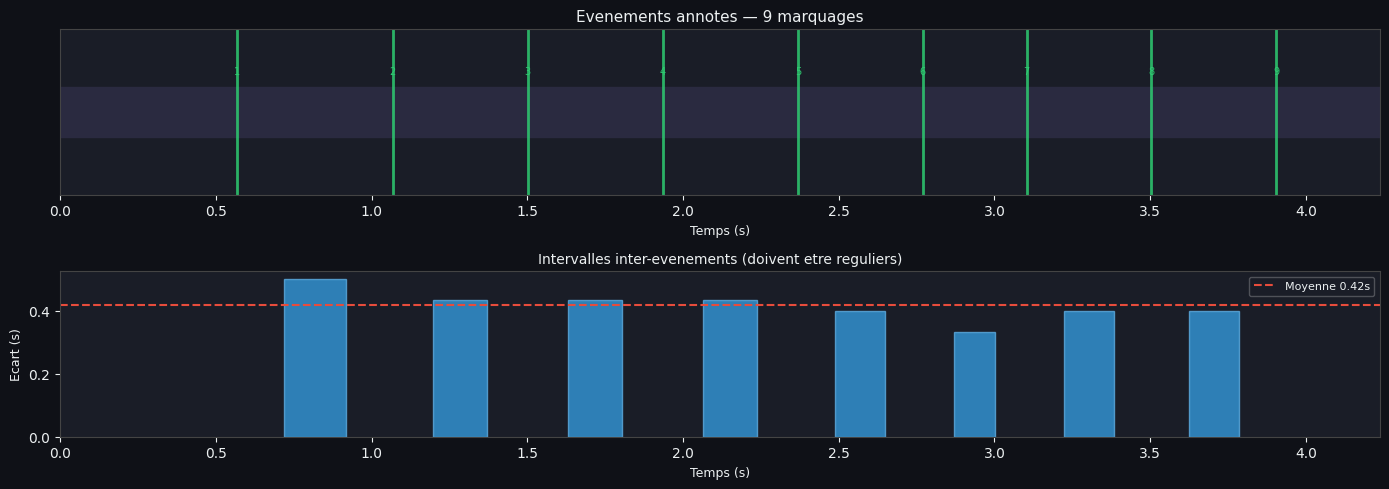

,event_id,frame_peak,time_sec,gap_to_next_sec
0,1,17,0.567,0.501
1,2,32,1.068,0.434
2,3,45,1.502,0.434
3,4,58,1.935,0.434
4,5,71,2.369,0.400
5,6,83,2.769,0.334
6,7,93,3.103,0.400
7,8,105,3.504,0.400
8,9,117,3.904,NaN


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

if not marks:
    print("Aucun marquage — retourner a la Cellule 4 et annoter d'abord")
else:
    # Convertir indices caches -> indices reels
    real_peaks = sorted([m * STRIDE for m in marks])
    times      = [p / FPS for p in real_peaks]
    gaps       = [times[i+1] - times[i] for i in range(len(times)-1)]

    print(f"{len(real_peaks)} evenements marques")
    print(f"   Periode couverte : {times[0]:.2f}s -> {times[-1]:.2f}s")
    if gaps:
        print(f"   Ecart moyen      : {np.mean(gaps):.2f}s")
        print(f"   Min / Max ecart  : {min(gaps):.2f}s  /  {max(gaps):.2f}s")
        if min(gaps) < 0.2:
            print("   Certains ecarts <0.2s — double marquage ? Utiliser UNDO pour corriger")
        if max(gaps) > 5.0:
            print("   Certains ecarts >5s — evenement manque ?")

    # Graphique 1 : frames marquees sur la timeline
    fig, axes = plt.subplots(2, 1, figsize=(14, 5))
    fig.patch.set_facecolor("#0f1117")

    ax = axes[0]
    ax.set_facecolor("#1a1d27")
    ax.set_xlim(0, N_FRAMES / FPS)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel("Temps (s)", color="#ecf0f1", fontsize=9)
    ax.set_title(f"Evenements annotes — {len(real_peaks)} marquages", color="#ecf0f1", fontsize=11)
    ax.tick_params(colors="#ecf0f1")
    for sp in ax.spines.values(): sp.set_color("#444")

    # Barre de duree totale
    ax.add_patch(mpatches.Rectangle((0, 0.35), N_FRAMES/FPS, 0.3,
                 color="#2a2a40", zorder=1))
    # Marqueurs d'evenements
    for t in times:
        ax.axvline(t, color="#2ecc71", lw=2, alpha=0.85, zorder=2)
    # Labels
    for i, t in enumerate(times):
        ax.text(t, 0.72, str(i+1), fontsize=7, color="#2ecc71",
                ha="center", va="bottom")

    # Graphique 2 : intervalles entre evenements
    ax2 = axes[1]
    ax2.set_facecolor("#1a1d27")
    if gaps:
        x = [(times[i] + times[i+1])/2 for i in range(len(gaps))]
        ax2.bar(x, gaps, width=np.array(gaps)*0.4,
                color="#3498db", alpha=0.8, edgecolor="#5dade2")
        ax2.axhline(np.mean(gaps), color="#e74c3c", lw=1.5,
                    linestyle="--", label=f"Moyenne {np.mean(gaps):.2f}s")
        ax2.set_xlabel("Temps (s)", color="#ecf0f1", fontsize=9)
        ax2.set_ylabel("Ecart (s)", color="#ecf0f1", fontsize=9)
        ax2.set_title("Intervalles inter-evenements (doivent etre reguliers)", color="#ecf0f1", fontsize=10)
        ax2.legend(fontsize=8, framealpha=0.3, labelcolor="#ecf0f1", facecolor="#1a1d27")
        ax2.tick_params(colors="#ecf0f1")
        for sp in ax2.spines.values(): sp.set_color("#444")
        ax2.set_xlim(0, N_FRAMES/FPS)

    plt.tight_layout()
    plt.show()

    # Tableau
    import pandas as pd
    preview_df = pd.DataFrame({
        "event_id":   range(1, len(real_peaks)+1),
        "frame_peak": real_peaks,
        "time_sec":   [round(t, 3) for t in times],
        "gap_to_next_sec": [round(g, 3) for g in gaps] + [None],
    })
    from IPython.display import display
    display(preview_df)

## Cellule 6 — Verification visuelle
> Affiche la frame exacte de chaque marquage pour confirmer visuellement.

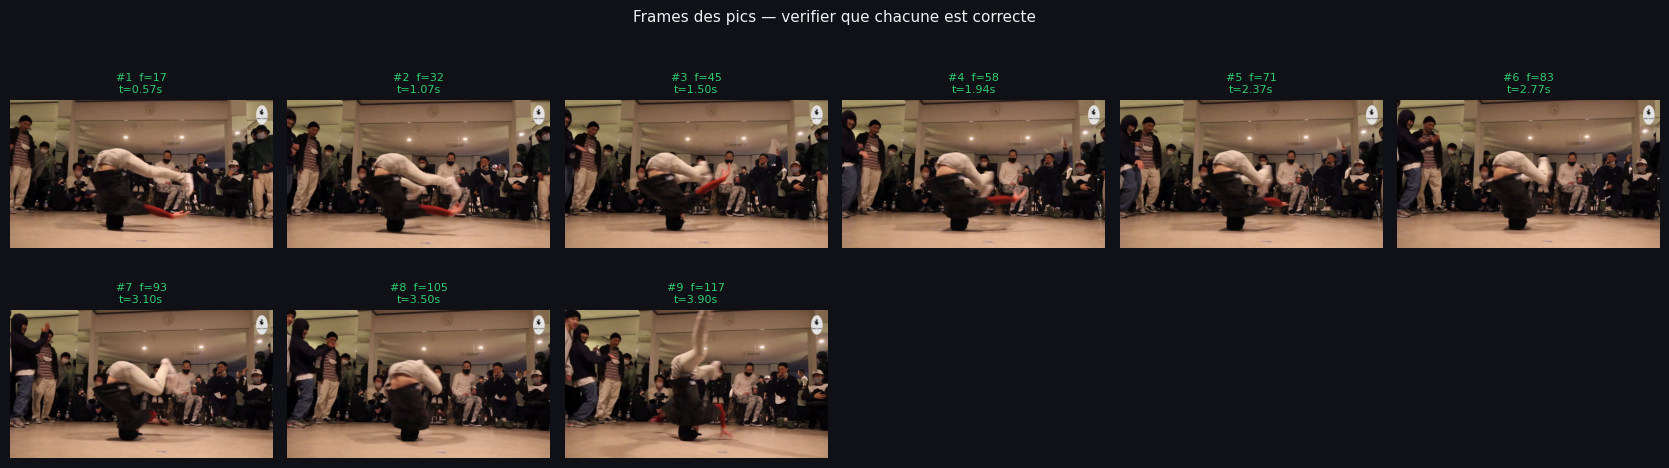

Si une frame semble incorrecte : retourner Cellule 4, utiliser UNDO, re-marquer


In [9]:
if not marks:
    print("Aucun marquage")
else:
    real_peaks = sorted([m * STRIDE for m in marks])
    n = len(real_peaks)
    cols = min(n, 6)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.8, rows * 2.5))
    fig.patch.set_facecolor("#0f1117")
    axes = np.array(axes).flatten() if n > 1 else [axes]

    cap = cv2.VideoCapture(VIDEO_PATH)
    for i, (ax, frame_idx) in enumerate(zip(axes, real_peaks)):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ok, frame = cap.read()
        if ok:
            ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_facecolor("#0f1117")
        ax.set_title(f"#{i+1}  f={frame_idx}\nt={frame_idx/FPS:.2f}s",
                     color="#2ecc71", fontsize=8)
        ax.axis("off")
    cap.release()

    # Masquer les axes inutilises
    for ax in axes[n:]:
        ax.set_visible(False)

    plt.suptitle("Frames des pics — verifier que chacune est correcte",
                 color="#ecf0f1", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

    print("Si une frame semble incorrecte : retourner Cellule 4, utiliser UNDO, re-marquer")

## Cellule 7 — Export CSV
> Executer quand les marquages sont confirmes. Telecharge `ground_truth.csv`.

In [10]:
from google.colab import files
import pandas as pd, os

if not marks:
    print("Rien a exporter — annoter dans la Cellule 4 d'abord")
else:
    real_peaks = sorted([m * STRIDE for m in marks])
    times      = [round(p / FPS, 3) for p in real_peaks]

    gt_df = pd.DataFrame({
        "event_id":   range(1, len(real_peaks)+1),
        "frame_peak": real_peaks,
        "time_sec":   times,
    })

    OUT_PATH = "/content/ground_truth.csv"
    gt_df.to_csv(OUT_PATH, index=False)

    print(f"Exporte {len(real_peaks)} evenements -> {OUT_PATH}")
    print()
    print(gt_df.to_string(index=False))
    print()
    print("Telechargement...")
    files.download(OUT_PATH)

    # Chemin disponible pour le notebook benchmark
    GT_PATH = OUT_PATH
    GT_PEAKS = real_peaks
    print(f"\nGT_PATH = '{GT_PATH}'  (pret pour le notebook benchmark)")

Exporte 9 evenements -> /content/ground_truth.csv

 event_id  frame_peak  time_sec
        1          17     0.567
        2          32     1.068
        3          45     1.502
        4          58     1.935
        5          71     2.369
        6          83     2.769
        7          93     3.103
        8         105     3.504
        9         117     3.904

Telechargement...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


GT_PATH = '/content/ground_truth.csv'  (pret pour le notebook benchmark)
